# Actividad 4: Clasificación Multiclase con Scikit Learn y TensorFlow sobre Dataset Diamonds

**Objetivo:** Predecir la variable `cut` (corte) de un diamante utilizando modelos de clasificación multiclase.

**Dataset:** Diamonds (disponible en Seaborn)

**Autor:** [Tu Nombre y Apellido]

---

## 1. Importar Librerías Necesarias

In [1]:
# La actividad exige usar Pandas, Seaborn, Scikit-Learn y TensorFlow Keras; importamos todo al inicio.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Scikit-learn para ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow y Keras para Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

print(f"Versión de Pandas: {pd.__version__}")
print(f"Versión de TensorFlow: {tf.__version__}")

Versión de Pandas: 2.2.2
Versión de TensorFlow: 2.19.0


## 2. Cargar el Dataset y Estadísticas Descriptivas

In [2]:
# El enunciado especifica usar el dataset 'diamonds' disponible públicamente en la librería seaborn.
df = sns.load_dataset('diamonds')

# Mostrar las primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())

Primeras 5 filas del dataset:
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [ ]:
# Apartado 1: revisamos tipos de datos y cantidad de registros como parte de las estadísticas descriptivas.
print("Información del dataset:")
print(df.info())
print(f"Dimensiones del dataset: {df.shape}")

\nInformación del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None
\nDimensiones del dataset: (53940, 10)


In [4]:
# Apartado 1: describe() muestra media, desviación, min/max de cada variable numérica con Pandas.
print("Estadísticas descriptivas de variables numéricas:")
df.describe()

Estadísticas descriptivas de variables numéricas:


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
# Apartado 1: usamos include='category' porque seaborn carga cut/color/clarity como tipo category, no object.
print("Estadísticas descriptivas de variables categóricas:")
df.describe(include='category')

Estadísticas descriptivas de variables categóricas:


,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


In [ ]:
# Apartado 1: inspeccionamos 'cut', la variable a predecir; tiene 5 categorías → clasificación multiclase.
print("Distribución de la variable objetivo 'cut':")
print(df['cut'].value_counts())
print(f"Categorías de 'cut': {df['cut'].unique()}")

\nDistribución de la variable objetivo 'cut':
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64
\nCategorías de 'cut': ['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']


## 3. Limpieza de Datos

### 3.1 Detección de Valores Nulos

In [ ]:
# Apartado 2 (limpieza): la rúbrica exige detectar valores nulos antes de cualquier modelado.
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"Total de valores nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
\nTotal de valores nulos: 0


### 3.2 Detección y Corrección de Tipos de Datos

In [ ]:
# Apartado 2 (limpieza): la rúbrica pide corregir tipos de datos y verificar inconsistencias.
print("Tipos de datos por columna:")
print(df.dtypes)

# Los tipos de datos parecen correctos en el dataset diamonds
# Verificar si hay valores extraños o inconsistentes
print("Valores únicos de variables categóricas:")
for col in ['cut', 'color', 'clarity']:
    print(f"{col}: {df[col].unique()}")

Tipos de datos por columna:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object
\nValores únicos de variables categóricas:
cut: ['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
color: ['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity: ['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']


### 3.3 Detección de Duplicados

In [9]:
# Apartado 2 (limpieza): la rúbrica exige eliminar duplicados para no sesgar el entrenamiento.
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

if duplicados > 0:
    print("Eliminando duplicados...")
    df = df.drop_duplicates()
    print(f"Filas restantes después de eliminar duplicados: {df.shape[0]}")
else:
    print("No se encontraron duplicados.")

Número de filas duplicadas: 146
Eliminando duplicados...
Filas restantes después de eliminar duplicados: 53794


### 3.4 Identificación y Tratamiento de Outliers

In [ ]:
# Apartado 2 (limpieza): la rúbrica pide identificar y tratar outliers; adicionalmente eliminamos
# filas con dimensiones físicamente imposibles (x, y o z = 0).
def detect_outliers_iqr(df, columns):
    outlier_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_step = 1.5 * IQR
        outlier_list = df[(df[col] < Q1 - outlier_step) | (df[col] > Q3 + outlier_step)].index
        outlier_indices.extend(outlier_list)
    outlier_indices = list(set(outlier_indices))
    return outlier_indices

# Columnas numéricas para detectar outliers
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
outliers = detect_outliers_iqr(df, numeric_cols)

print(f"Número de outliers detectados: {len(outliers)}")
print(f"Porcentaje de outliers: {len(outliers)/len(df)*100:.2f}%")

# Verificar valores anómalos (como dimensiones = 0)
print("Valores anómalos en dimensiones (x, y, z = 0):")
print(f"Filas con x=0: {(df['x'] == 0).sum()}")
print(f"Filas con y=0: {(df['y'] == 0).sum()}")
print(f"Filas con z=0: {(df['z'] == 0).sum()}")

# Eliminar filas con dimensiones = 0 (valores imposibles)
df_clean = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)].copy()
print(f"Filas después de eliminar valores anómalos: {df_clean.shape[0]}")

Número de outliers detectados: 6378
Porcentaje de outliers: 11.86%
\nValores anómalos en dimensiones (x, y, z = 0):
Filas con x=0: 7
Filas con y=0: 6
Filas con z=0: 19
\nFilas después de eliminar valores anómalos: 53775


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 EDA Univariante

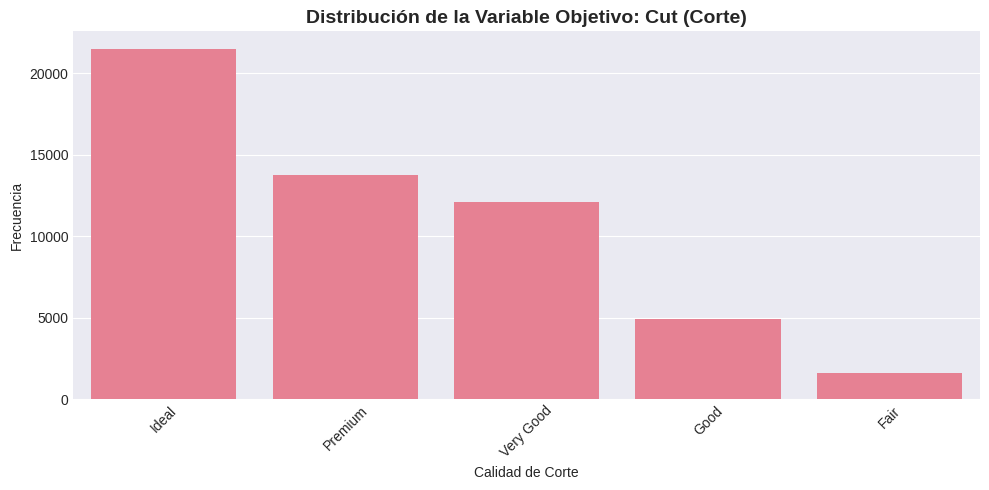

Proporción de cada categoría:
cut
Ideal        39.953510
Premium      25.545328
Very Good    22.441655
Good          9.089726
Fair          2.969781
Name: proportion, dtype: float64


In [11]:
# Apartado 3 (EDA univariante): visualizamos la distribución de 'cut' para entender el desbalance de clases.
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='cut', order=df_clean['cut'].value_counts().index)
plt.title('Distribución de la Variable Objetivo: Cut (Corte)', fontsize=14, fontweight='bold')
plt.xlabel('Calidad de Corte')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Proporción de cada categoría:")
print(df_clean['cut'].value_counts(normalize=True) * 100)

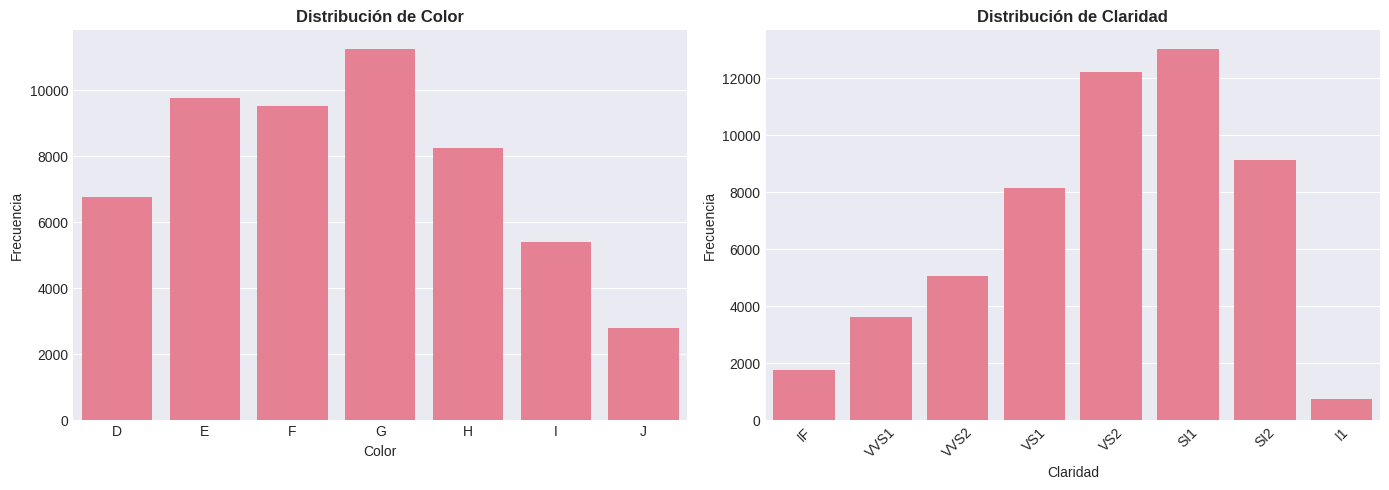

In [12]:
# Apartado 3 (EDA univariante): analizamos color y clarity, las otras dos variables categóricas del dataset.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x='color', ax=axes[0])
axes[0].set_title('Distribución de Color', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Color')
axes[0].set_ylabel('Frecuencia')

sns.countplot(data=df_clean, x='clarity', ax=axes[1])
axes[1].set_title('Distribución de Claridad', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Claridad')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

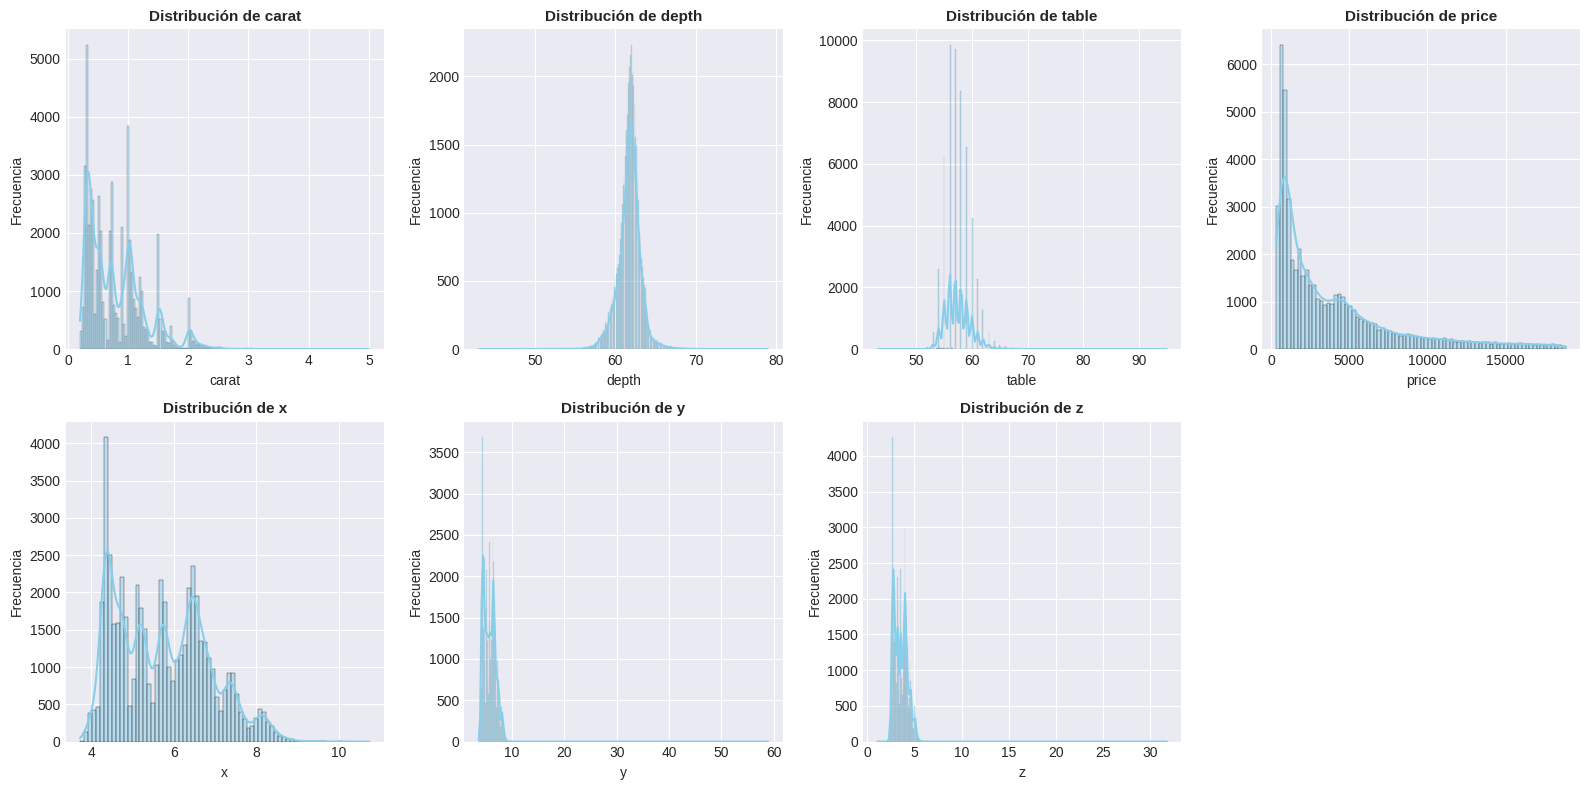

In [13]:
# Apartado 3 (EDA univariante): histogramas con KDE de todas las variables numéricas para ver su forma.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

numeric_features = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

for i, col in enumerate(numeric_features):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Ocultar el último subplot si no se usa
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### 4.2 EDA Bivariante

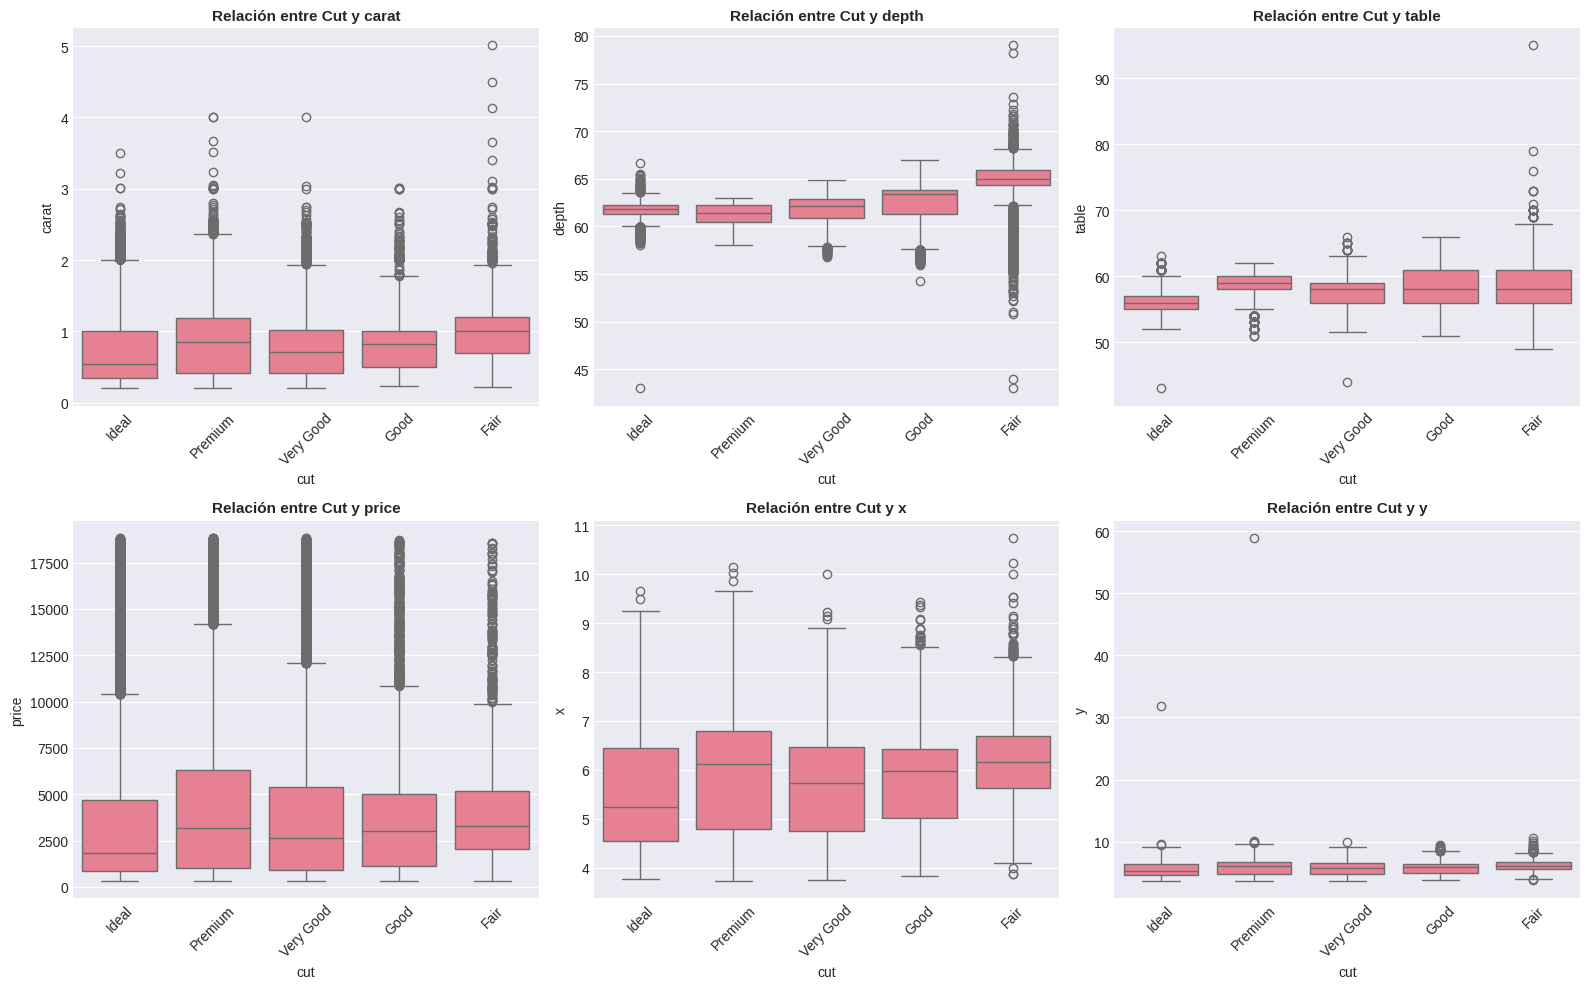

In [14]:
# Apartado 3 (EDA bivariante): boxplots para ver cómo varía cada variable numérica según la clase de corte.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

numeric_features_bi = ['carat', 'depth', 'table', 'price', 'x', 'y']

for i, col in enumerate(numeric_features_bi):
    sns.boxplot(data=df_clean, x='cut', y=col, ax=axes[i])
    axes[i].set_title(f'Relación entre Cut y {col}', fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

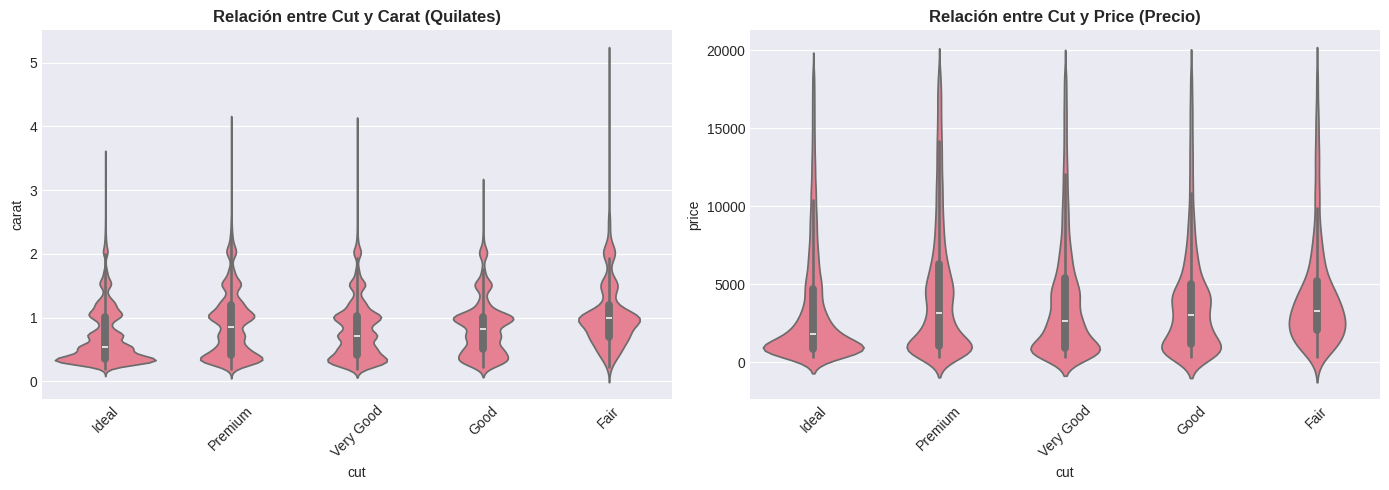

In [15]:
# Apartado 3 (EDA bivariante): violinplots muestran también la densidad, complementando los boxplots.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df_clean, x='cut', y='carat', ax=axes[0])
axes[0].set_title('Relación entre Cut y Carat (Quilates)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(data=df_clean, x='cut', y='price', ax=axes[1])
axes[1].set_title('Relación entre Cut y Price (Precio)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Apartado 3 (EDA bivariante): tablas de contingencia para ver la relación entre las variables categóricas.
print("Tabla de contingencia: Cut vs Color")
print(pd.crosstab(df_clean['cut'], df_clean['color'], margins=True))

print("n" + "="*50 + "n")

print("Tabla de contingencia: Cut vs Clarity")
print(pd.crosstab(df_clean['cut'], df_clean['clarity'], margins=True))

Tabla de contingencia: Cut vs Color
color         D     E     F      G     H     I     J    All
cut                                                        
Ideal      2823  3893  3818   4863  3104  2090   894  21485
Premium    1598  2331  2320   2915  2346  1421   806  13737
Very Good  1510  2399  2163   2298  1818  1203   677  12068
Good        660   931   907    867   699   518   306   4888
Fair        163   222   309    311   299   174   119   1597
All        6754  9776  9517  11254  8266  5406  2802  53775
\n==================================================\n
Tabla de contingencia: Cut vs Clarity
clarity      IF  VVS1  VVS2   VS1    VS2    SI1   SI2   I1    All
cut                                                              
Ideal      1206  2039  2597  3582   5054   4268  2593  146  21485
Premium     230   615   869  1984   3349   3565  2922  203  13737
Very Good   268   789  1235  1774   2586   3236  2096   84  12068
Good         71   186   286   646    978   1555  1072   94   

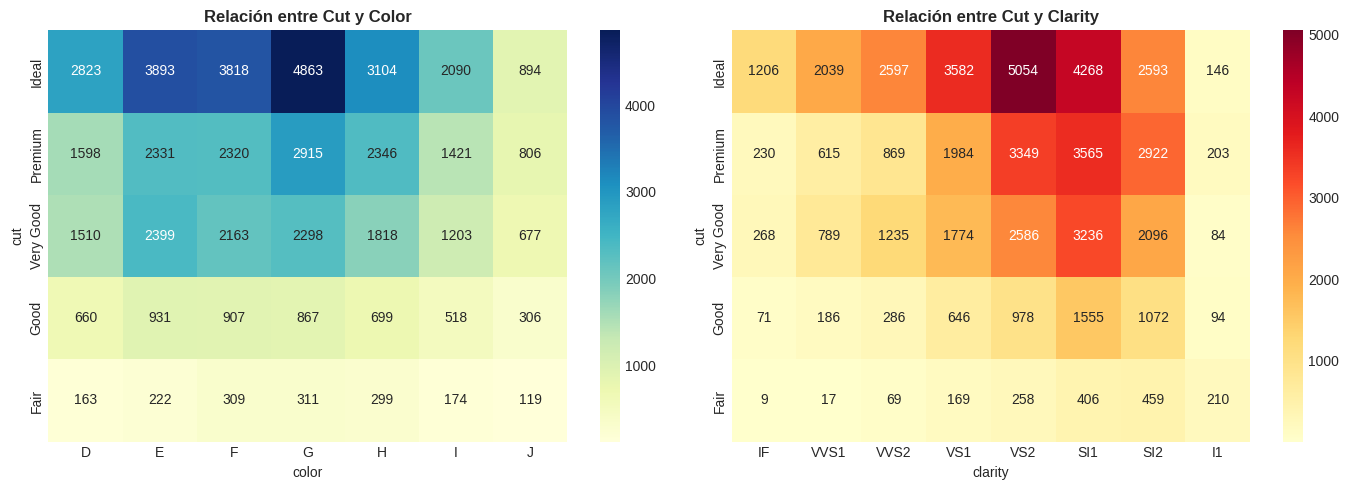

In [17]:
# Apartado 3 (EDA bivariante): heatmap de las tablas de contingencia para visualizar patrones rápidamente.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cut vs Color
ct_color = pd.crosstab(df_clean['cut'], df_clean['color'])
sns.heatmap(ct_color, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Relación entre Cut y Color', fontsize=12, fontweight='bold')

# Cut vs Clarity
ct_clarity = pd.crosstab(df_clean['cut'], df_clean['clarity'])
sns.heatmap(ct_clarity, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Relación entre Cut y Clarity', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.3 EDA Multivariante

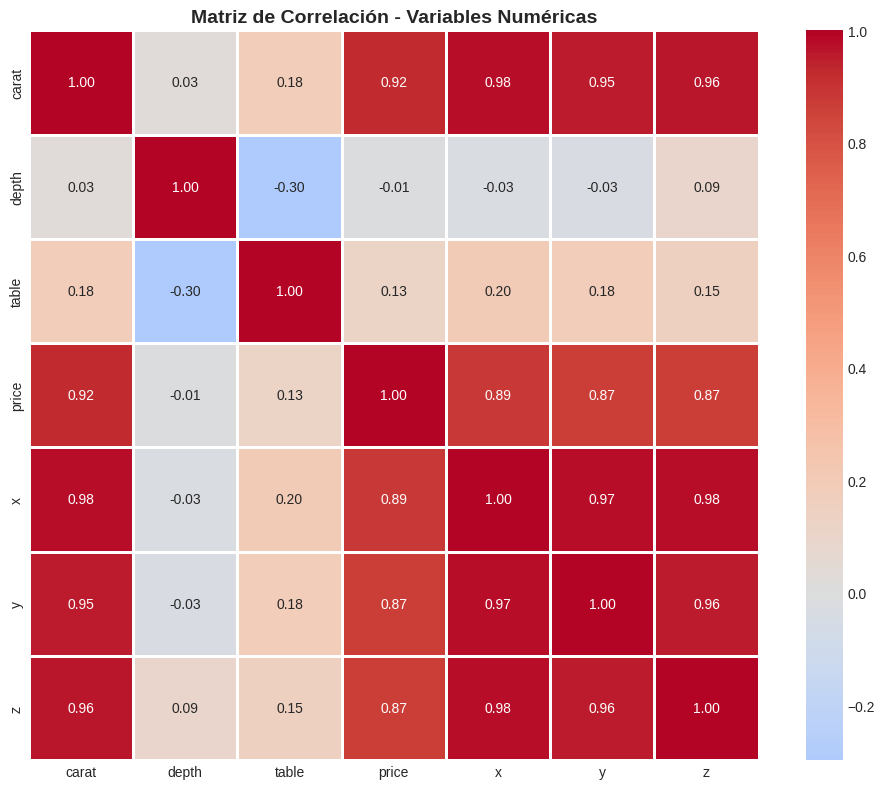

Correlaciones más fuertes (> 0.8 o < -0.8):
carat vs price: 0.922
carat vs x: 0.978
carat vs y: 0.954
carat vs z: 0.961
price vs x: 0.887
price vs y: 0.868
price vs z: 0.868
x vs y: 0.975
x vs z: 0.975
y vs z: 0.957


In [18]:
# Apartado 3 (EDA multivariante): la matriz de correlación detecta variables redundantes o muy correlacionadas.
correlation_matrix = df_clean[numeric_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identificar correlaciones fuertes
print("Correlaciones más fuertes (> 0.8 o < -0.8):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            print(f"{correlation_matrix.columns[i]} vs {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

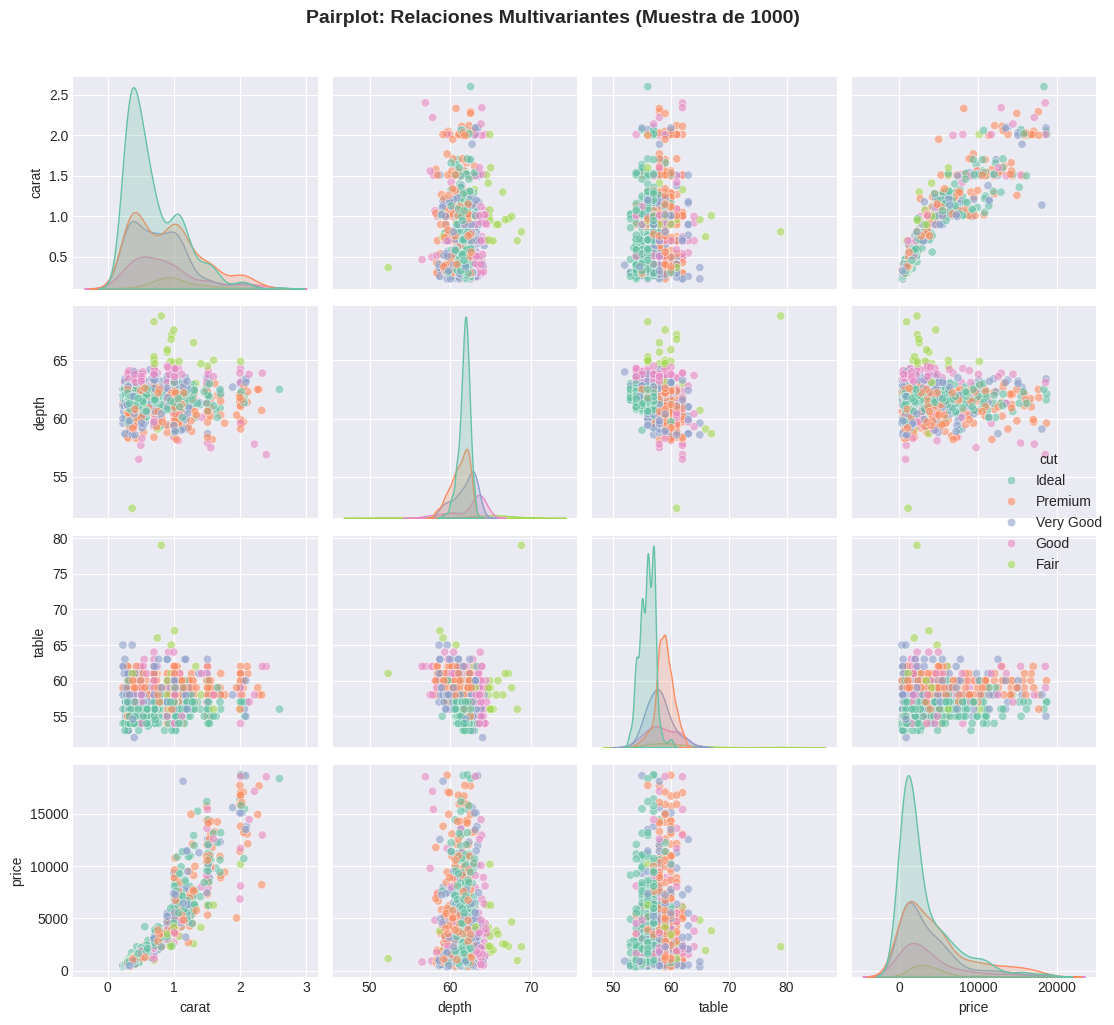

In [19]:
# Apartado 3 (EDA multivariante): pairplot cruzando múltiples variables a la vez coloreado por clase.
# Usamos muestra de 1000 para agilizar la generación del gráfico.
sample_df = df_clean.sample(n=1000, random_state=42)

sns.pairplot(sample_df, hue='cut', vars=['carat', 'depth', 'table', 'price'],
             palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot: Relaciones Multivariantes (Muestra de 1000)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

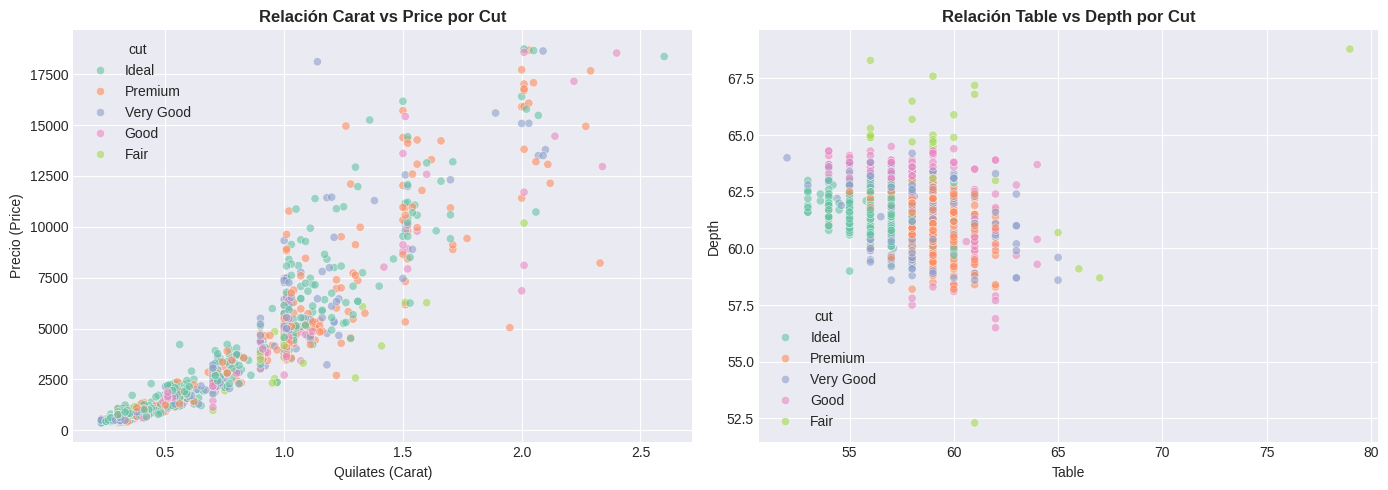

In [20]:
# Apartado 3 (EDA multivariante): scatterplots con hue='cut' para ver si las clases son separables.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Carat vs Price coloreado por Cut
sns.scatterplot(data=sample_df, x='carat', y='price', hue='cut',
                palette='Set2', alpha=0.6, ax=axes[0])
axes[0].set_title('Relación Carat vs Price por Cut', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Quilates (Carat)')
axes[0].set_ylabel('Precio (Price)')

# Table vs Depth coloreado por Cut
sns.scatterplot(data=sample_df, x='table', y='depth', hue='cut',
                palette='Set2', alpha=0.6, ax=axes[1])
axes[1].set_title('Relación Table vs Depth por Cut', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Table')
axes[1].set_ylabel('Depth')

plt.tight_layout()
plt.show()

## 5. Preparación de Datos para el Modelado

### 5.1 Codificación de Variables Categóricas

In [ ]:
# Apartado 4 (preparación): separamos X e y antes de codificar para no incluir la variable objetivo como feature.
df_modelo = df_clean.copy()

# Separar la variable objetivo
y = df_modelo['cut']

# Eliminar la variable objetivo del dataframe de características
X = df_modelo.drop('cut', axis=1)

print("Variables disponibles para el modelo:")
print(X.columns.tolist())
print(f"Variable objetivo: cut con {y.nunique()} clases")

Variables disponibles para el modelo:
['carat', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
\nVariable objetivo: cut con 5 clases


In [ ]:
# Apartado 4 (preparación): la rúbrica exige usar get_dummies de Pandas para codificar variables categóricas.
X_encoded = pd.get_dummies(X, columns=['color', 'clarity'], drop_first=True)

print(f"Dimensiones después de codificación: {X_encoded.shape}")
print(f"Columnas codificadas:")
print(X_encoded.columns.tolist())

Dimensiones después de codificación: (53775, 20)
\nColumnas codificadas:
['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J', 'clarity_VVS1', 'clarity_VVS2', 'clarity_VS1', 'clarity_VS2', 'clarity_SI1', 'clarity_SI2', 'clarity_I1']


In [23]:
# Apartado 4 (preparación): codificamos 'cut' a entero con LabelEncoder para que los modelos la procesen.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Mapeo de clases:")
for i, clase in enumerate(label_encoder.classes_):
    print(f"{i}: {clase}")

# Guardar el mapeo para referencia futura
class_mapping = {i: clase for i, clase in enumerate(label_encoder.classes_)}

Mapeo de clases:
0: Fair
1: Good
2: Ideal
3: Premium
4: Very Good


### 5.2 División de Datos: Train/Test Split

In [ ]:
# Apartado 4 (preparación): la rúbrica exige train_test_split; usamos stratify para mantener proporciones de clases.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Número de características: {X_train.shape[1]}")

Tamaño del conjunto de entrenamiento: 43020 (80.0%)
Tamaño del conjunto de prueba: 10755 (20.0%)
\nNúmero de características: 20


### 5.3 Escalado de Variables Numéricas

In [ ]:
# Apartado 4 (preparación): la rúbrica exige escalar columnas numéricas; fit solo con train para evitar data leakage.
scaler = StandardScaler()

# Ajustar el scaler solo con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para mantener los nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Datos escalados correctamente.")
print(f"Estadísticas del conjunto de entrenamiento escalado:")
print(X_train_scaled.describe())

Datos escalados correctamente.
\nEstadísticas del conjunto de entrenamiento escalado:
              carat         depth         table         price             x  \
count  4.302000e+04  4.302000e+04  4.302000e+04  4.302000e+04  4.302000e+04   
mean   1.152856e-16  2.224782e-15  4.638678e-16 -1.024027e-17  9.376455e-16   
std    1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00   
min   -1.263635e+00 -1.314175e+01 -6.481161e+00 -9.059605e-01 -1.790463e+00   
25%   -8.417942e-01 -5.254745e-01 -6.533353e-01 -7.490614e-01 -9.153779e-01   
50%   -2.090329e-01  3.524887e-02 -2.050410e-01 -3.830052e-01 -3.136286e-02   
75%    5.080967e-01  5.258819e-01  6.915476e-01  3.505465e-01  7.187105e-01   
max    8.881639e+00  1.153008e+01  1.683014e+01  3.720278e+00  4.469077e+00   

                  y             z       color_E       color_F       color_G  \
count  4.302000e+04  4.302000e+04  4.302000e+04  4.302000e+04  4.302000e+04   
mean   5.719687e-16  9.480510e-17 -8.060085e

## 6. Modelado con Scikit-Learn

### 6.1 Modelo 1: Random Forest Classifier

In [26]:
# Apartado 5 (modelado SK-Learn): Random Forest maneja bien multiclase y permite ver importancia de variables.
print("Entrenando Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Hacer predicciones
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluar el modelo
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy (Random Forest): {accuracy_rf:.4f}")

print("Reporte de Clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Entrenando Random Forest Classifier...
Accuracy (Random Forest): 0.7746
Reporte de Clasificación (Random Forest):
              precision    recall  f1-score   support

        Fair       0.91      0.87      0.89       319
        Good       0.80      0.68      0.74       978
       Ideal       0.82      0.92      0.87      4297
     Premium       0.73      0.81      0.77      2747
   Very Good       0.68      0.50      0.58      2414

    accuracy                           0.77     10755
   macro avg       0.79      0.76      0.77     10755
weighted avg       0.77      0.77      0.77     10755



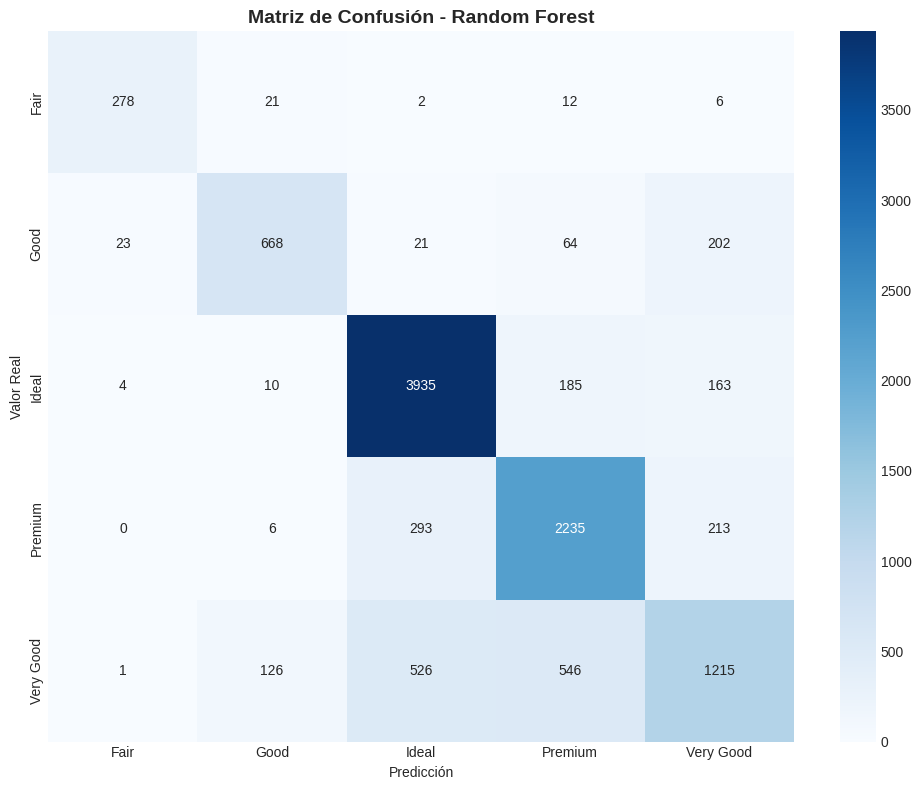

In [27]:
# Evaluación: la matriz de confusión muestra en qué clases comete más errores el modelo.
plt.figure(figsize=(10, 8))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

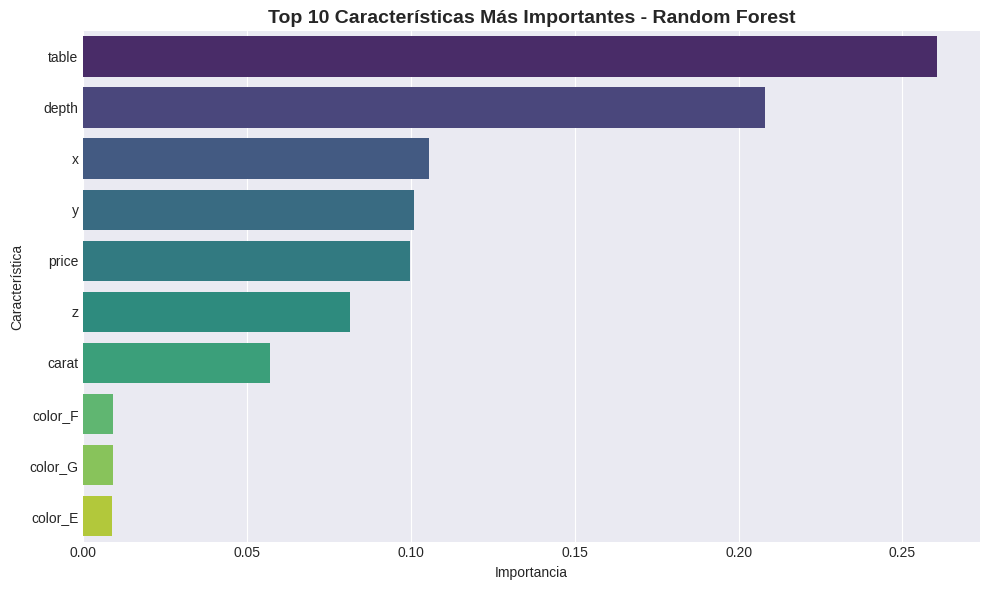

Top 10 características más importantes:
   feature  importance
2    table    0.260623
1    depth    0.208112
4        x    0.105482
5        y    0.100983
3    price    0.099690
6        z    0.081481
0    carat    0.057071
8  color_F    0.009112
9  color_G    0.009104
7  color_E    0.008735


In [28]:
# Random Forest permite obtener la importancia de cada feature, útil para interpretar el modelo.
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Características Más Importantes - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

print("Top 10 características más importantes:")
print(feature_importance.head(10))

### 6.2 Modelo 2: Logistic Regression

In [29]:
# Apartado 5 (modelado SK-Learn): regresión logística multinomial como modelo lineal de referencia.
print("Entrenando Logistic Regression...")
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                               max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)

# Hacer predicciones
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluar el modelo
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy (Logistic Regression): {accuracy_lr:.4f}")

print("Reporte de Clasificación (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

Entrenando Logistic Regression...


Accuracy (Logistic Regression): 0.6503
Reporte de Clasificación (Logistic Regression):
              precision    recall  f1-score   support

        Fair       0.79      0.50      0.61       319
        Good       0.58      0.15      0.23       978
       Ideal       0.71      0.87      0.78      4297
     Premium       0.65      0.70      0.68      2747
   Very Good       0.49      0.43      0.46      2414

    accuracy                           0.65     10755
   macro avg       0.65      0.53      0.55     10755
weighted avg       0.64      0.65      0.63     10755



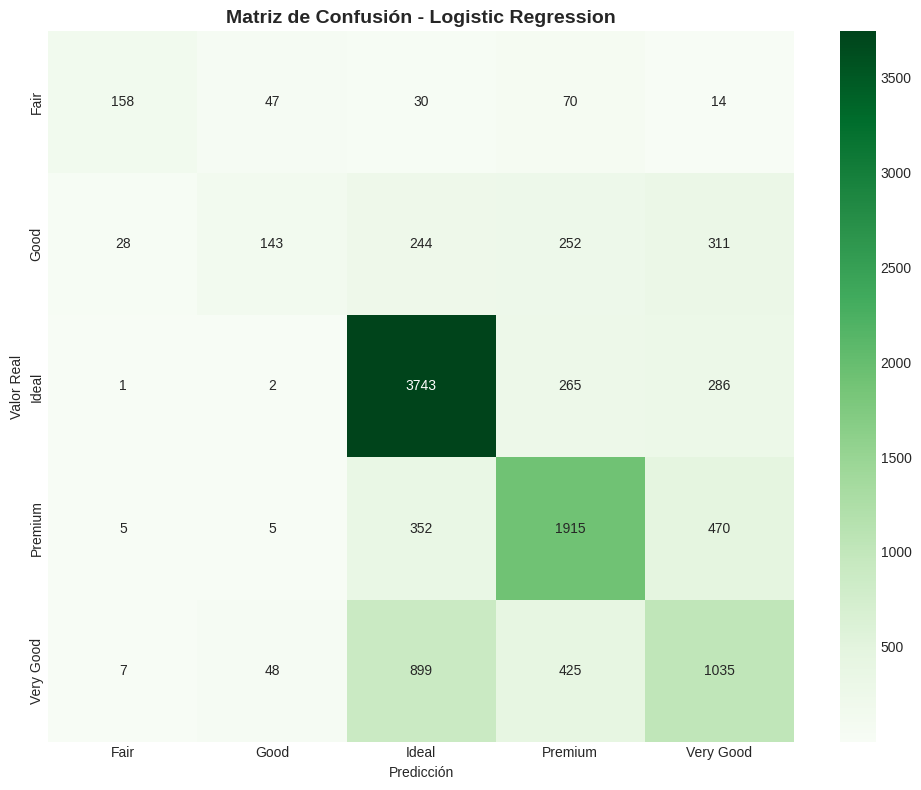

In [30]:
# Evaluación: comparamos la matriz de confusión con la de Random Forest para ver diferencias.
plt.figure(figsize=(10, 8))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

### 6.3 Modelo 3: Support Vector Classifier (SVC)

In [31]:
# Apartado 5 (modelado SK-Learn): SVC con kernel RBF captura relaciones no lineales entre variables.
# Entrenamos con muestra para reducir el tiempo de cómputo (SVC escala cuadráticamente).
print("Entrenando Support Vector Classifier (puede tardar unos minutos)...")

# Tomamos una muestra más pequeña para SVC
sample_size = 5000
indices = np.random.choice(X_train_scaled.shape[0], sample_size, replace=False)
X_train_sample = X_train_scaled.iloc[indices]
y_train_sample = y_train[indices]

svc_model = SVC(kernel='rbf', C=1.0, random_state=42)
svc_model.fit(X_train_sample, y_train_sample)

# Hacer predicciones
y_pred_svc = svc_model.predict(X_test_scaled)

# Evaluar el modelo
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy (SVC): {accuracy_svc:.4f}")
print("(Nota: Modelo entrenado con muestra de 5000 registros)")

print("Reporte de Clasificación (SVC):")
print(classification_report(y_test, y_pred_svc, target_names=label_encoder.classes_))

Entrenando Support Vector Classifier (puede tardar unos minutos)...
Accuracy (SVC): 0.6575
(Nota: Modelo entrenado con muestra de 5000 registros)
Reporte de Clasificación (SVC):
              precision    recall  f1-score   support

        Fair       0.95      0.52      0.67       319
        Good       0.57      0.38      0.46       978
       Ideal       0.75      0.91      0.82      4297
     Premium       0.60      0.75      0.66      2747
   Very Good       0.45      0.23      0.31      2414

    accuracy                           0.66     10755
   macro avg       0.66      0.56      0.58     10755
weighted avg       0.63      0.66      0.63     10755



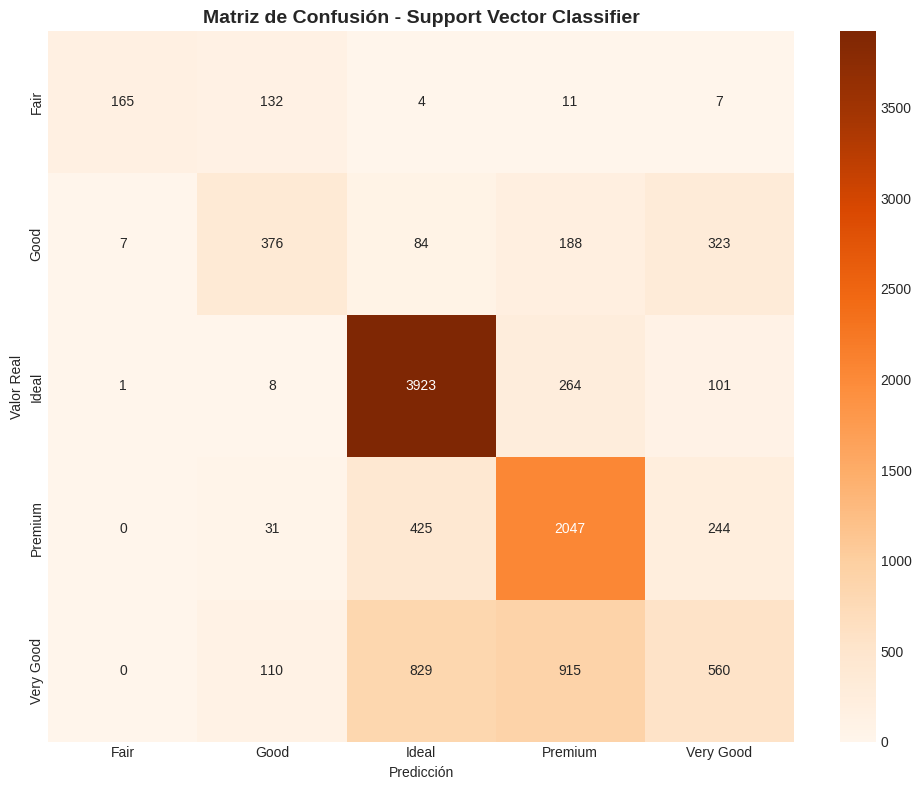

In [32]:
# Evaluación: matriz de confusión del SVC.
plt.figure(figsize=(10, 8))
cm_svc = confusion_matrix(y_test, y_pred_svc)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - Support Vector Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

### 6.4 Modelo 4: Decision Tree Classifier

In [33]:
# Apartado 5 (modelado SK-Learn): árbol de decisión, fácil de interpretar pero propenso a sobreajuste.
print("Entrenando Decision Tree Classifier...")
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Hacer predicciones
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluar el modelo
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy (Decision Tree): {accuracy_dt:.4f}")

print("Reporte de Clasificación (Decision Tree):")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

Entrenando Decision Tree Classifier...
Accuracy (Decision Tree): 0.7447
Reporte de Clasificación (Decision Tree):
              precision    recall  f1-score   support

        Fair       0.87      0.87      0.87       319
        Good       0.83      0.61      0.70       978
       Ideal       0.82      0.90      0.86      4297
     Premium       0.65      0.85      0.74      2747
   Very Good       0.67      0.38      0.49      2414

    accuracy                           0.74     10755
   macro avg       0.77      0.72      0.73     10755
weighted avg       0.74      0.74      0.73     10755



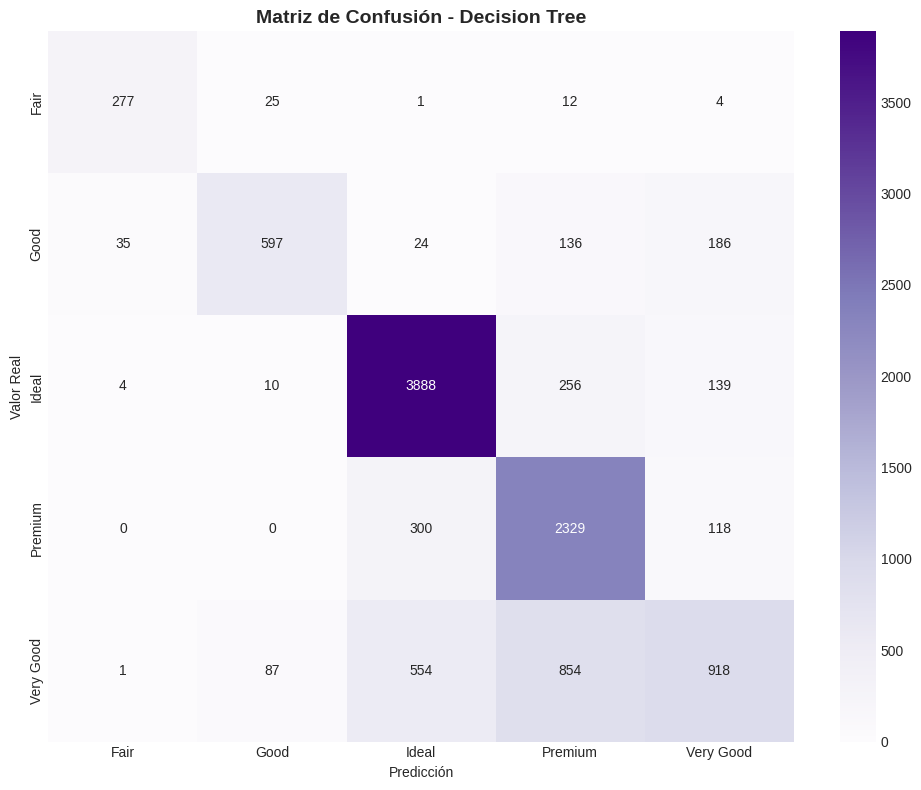

In [34]:
# Evaluación: matriz de confusión del árbol de decisión.
plt.figure(figsize=(10, 8))
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

### 6.5 Comparación de Modelos Scikit-Learn

n============================================================
COMPARACIÓN DE MODELOS SCIKIT-LEARN
             Modelo  Accuracy
      Random Forest  0.774616
      Decision Tree  0.744677
                SVC  0.657462
Logistic Regression  0.650302


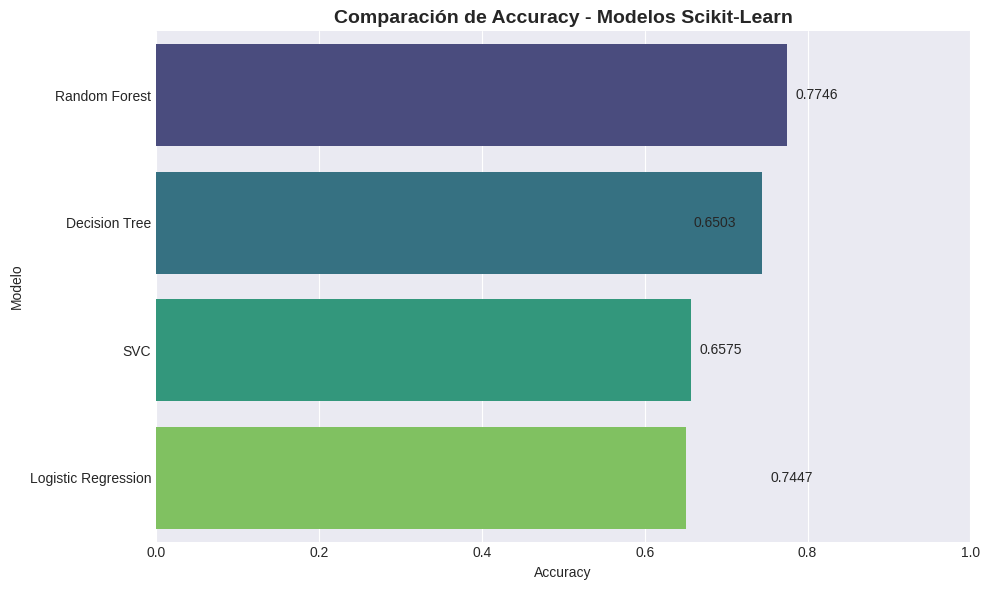

Mejor modelo: Random Forest con Accuracy de 0.7746


In [35]:
# Apartado 5: comparamos todos los modelos en una misma tabla para ver cuál obtiene mejor accuracy.
resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'Logistic Regression', 'SVC', 'Decision Tree'],
    'Accuracy': [accuracy_rf, accuracy_lr, accuracy_svc, accuracy_dt]
}).sort_values('Accuracy', ascending=False)

print("n" + "="*60)
print("COMPARACIÓN DE MODELOS SCIKIT-LEARN")
print("="*60)
print(resultados.to_string(index=False))
print("="*60)

# Gráfico de comparación
plt.figure(figsize=(10, 6))
sns.barplot(data=resultados, x='Accuracy', y='Modelo', palette='viridis')
plt.title('Comparación de Accuracy - Modelos Scikit-Learn', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy')
plt.ylabel('Modelo')
plt.xlim(0, 1)
for i, row in resultados.iterrows():
    plt.text(row['Accuracy'] + 0.01, i, f"{row['Accuracy']:.4f}", va='center')
plt.tight_layout()
plt.show()

print(f"Mejor modelo: {resultados.iloc[0]['Modelo']} con Accuracy de {resultados.iloc[0]['Accuracy']:.4f}")

## 7. Modelado con TensorFlow Keras

### 7.1 Preparación de Datos para TensorFlow

In [36]:
# Apartado 6 (TF): Keras con softmax necesita las etiquetas en formato one-hot (un vector por clase).
y_train_categorical = to_categorical(y_train, num_classes=len(label_encoder.classes_))
y_test_categorical = to_categorical(y_test, num_classes=len(label_encoder.classes_))

print(f"Shape de y_train_categorical: {y_train_categorical.shape}")
print(f"Shape de y_test_categorical: {y_test_categorical.shape}")
print(f"Número de clases: {len(label_encoder.classes_)}")
print(f"Número de características: {X_train_scaled.shape[1]}")

Shape de y_train_categorical: (43020, 5)
Shape de y_test_categorical: (10755, 5)
Número de clases: 5
Número de características: 20


### 7.2 Construcción del Modelo de Red Neuronal

In [37]:
# Apartado 6 (TF): red neuronal con capas Dense y Dropout; Dropout reduce sobreajuste en clasificación.
model = Sequential([
    # Capa de entrada
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    # Capas ocultas
    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    # Capa de salida (softmax para clasificación multiclase)
    Dense(len(label_encoder.classes_), activation='softmax')
])

# Ver resumen del modelo
print("Arquitectura del modelo:")
model.summary()

Arquitectura del modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,189 (51.52 KB)

 Trainable params: 13,189 (51.52 KB)

 Non-trainable params: 0 (0.00 B)

### 7.3 Compilación del Modelo

In [38]:
# Apartado 6 (TF): categorical_crossentropy es la función de pérdida correcta para multiclase con softmax.
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo compilado correctamente.")

Modelo compilado correctamente.


### 7.4 Entrenamiento del Modelo

In [39]:
# Apartado 6 (TF): entrenamos con validation_split para monitorear sobreajuste en cada época.
print("Entrenando la red neuronal...")

history = model.fit(
    X_train_scaled, y_train_categorical,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    verbose=1
)

print("Entrenamiento completado.")

Entrenando la red neuronal...
Epoch 1/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.4399 - loss: 1.3420 - val_accuracy: 0.6675 - val_loss: 0.8887
Epoch 2/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6208 - loss: 0.9581 - val_accuracy: 0.6922 - val_loss: 0.8140
Epoch 3/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6551 - loss: 0.8928 - val_accuracy: 0.6989 - val_loss: 0.7908
Epoch 4/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6729 - loss: 0.8594 - val_accuracy: 0.7034 - val_loss: 0.7754
Epoch 5/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6765 - loss: 0.8402 - val_accuracy: 0.7061 - val_loss: 0.7691
Epoch 6/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6880 - loss: 0.8168 - val_accuracy: 0.7061 - val_loss: 0.7656
Epoch 7/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6912 - loss: 0.8038 - val_accuracy: 0.7040 - val_loss: 0.7656
Epoch 8/30
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6963 - 

### 7.5 Evaluación del Modelo

In [40]:
# Apartado 6 (TF): evaluamos sobre el conjunto de prueba para obtener la métrica final del modelo.
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_categorical, verbose=0)

print("="*60)
print("RESULTADOS DEL MODELO TENSORFLOW KERAS")
print("="*60)
print(f"Loss en conjunto de prueba: {test_loss:.4f}")
print(f"Accuracy en conjunto de prueba: {test_accuracy:.4f}")
print("="*60)

RESULTADOS DEL MODELO TENSORFLOW KERAS
Loss en conjunto de prueba: 0.6110
Accuracy en conjunto de prueba: 0.7649


In [41]:
# Apartado 6 (TF): argmax convierte las probabilidades softmax a la clase con mayor probabilidad.
y_pred_keras_proba = model.predict(X_test_scaled)
y_pred_keras = np.argmax(y_pred_keras_proba, axis=1)

# Reporte de clasificación
print("Reporte de Clasificación (TensorFlow Keras):")
print(classification_report(y_test, y_pred_keras, target_names=label_encoder.classes_))

337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Reporte de Clasificación (TensorFlow Keras):
              precision    recall  f1-score   support

        Fair       0.89      0.86      0.87       319
        Good       0.78      0.58      0.66       978
       Ideal       0.81      0.92      0.86      4297
     Premium       0.77      0.80      0.78      2747
   Very Good       0.63      0.52      0.57      2414

    accuracy                           0.76     10755
   macro avg       0.78      0.73      0.75     10755
weighted avg       0.76      0.76      0.76     10755



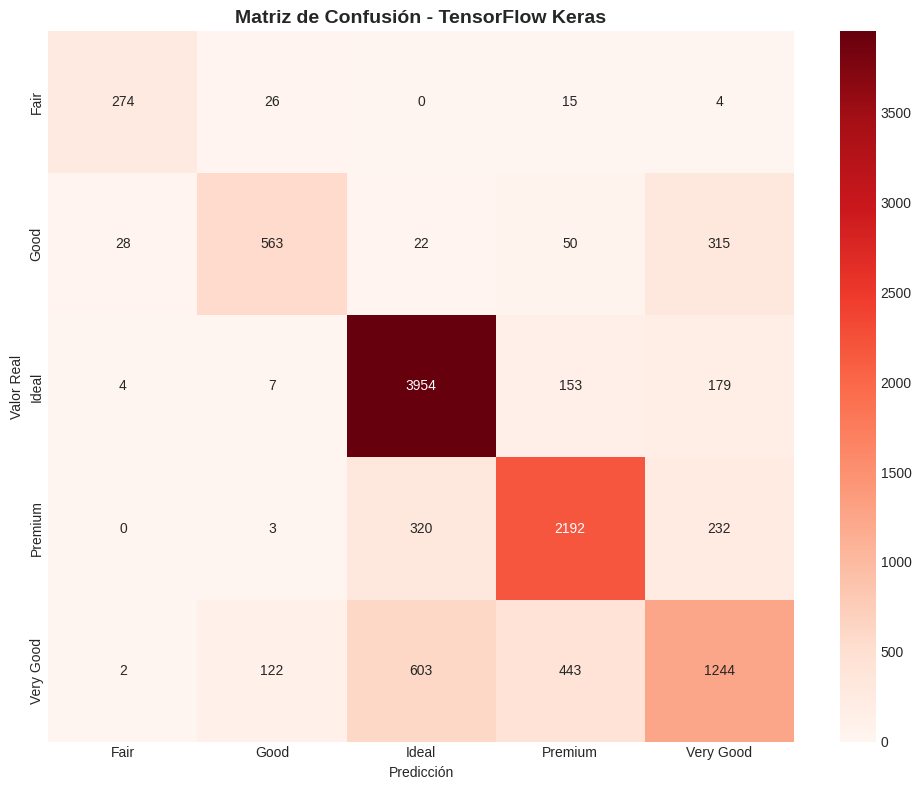

In [42]:
# Apartado 6 (TF): matriz de confusión para comparar errores del modelo TF con los de Scikit-Learn.
plt.figure(figsize=(10, 8))
cm_keras = confusion_matrix(y_test, y_pred_keras)
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Reds',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión - TensorFlow Keras', fontsize=14, fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

### 7.6 Visualización del Entrenamiento

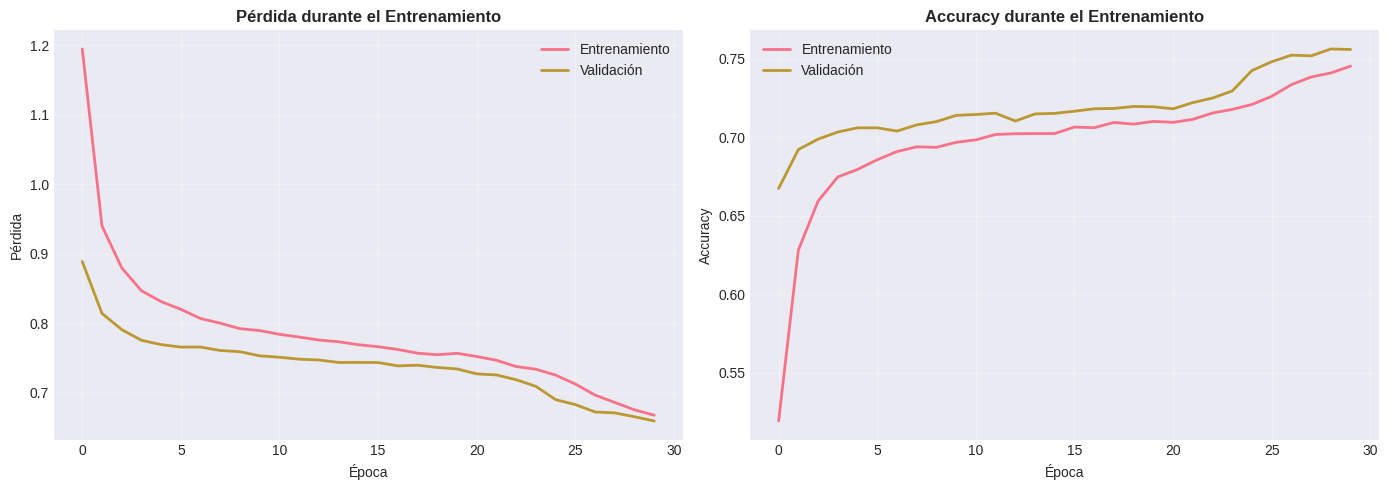

In [43]:
# Apartado 6 (TF): las curvas de pérdida y accuracy permiten detectar si hay overfitting o underfitting.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de pérdida
axes[0].plot(history.history['loss'], label='Entrenamiento', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validación', linewidth=2)
axes[0].set_title('Pérdida durante el Entrenamiento', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico de accuracy
axes[1].plot(history.history['accuracy'], label='Entrenamiento', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validación', linewidth=2)
axes[1].set_title('Accuracy durante el Entrenamiento', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Comparación Final de Todos los Modelos

n======================================================================
COMPARACIÓN FINAL DE TODOS LOS MODELOS
             Modelo  Accuracy          Tipo
      Random Forest  0.774616  Scikit-Learn
   TensorFlow Keras  0.764947 Deep Learning
      Decision Tree  0.744677  Scikit-Learn
                SVC  0.657462  Scikit-Learn
Logistic Regression  0.650302  Scikit-Learn


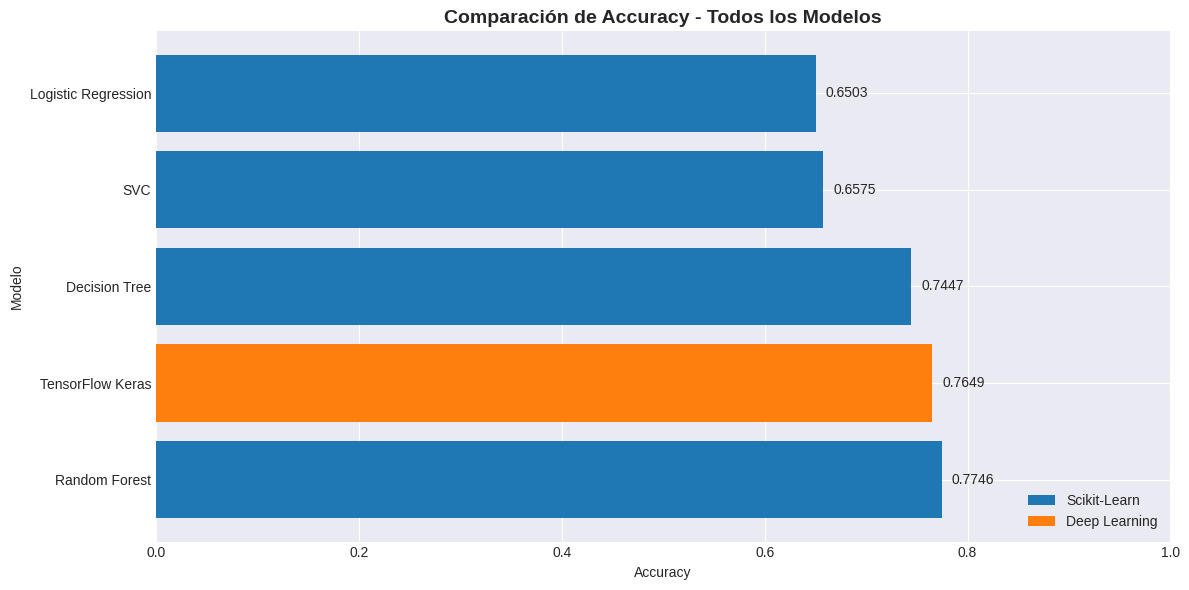

🏆 MEJOR MODELO: Random Forest con Accuracy de 0.7746


In [44]:
# Resumen final: comparamos SK-Learn y TF en una misma tabla para concluir qué enfoque es mejor.
resultados_finales = pd.DataFrame({
    'Modelo': ['Random Forest', 'Logistic Regression', 'SVC', 'Decision Tree', 'TensorFlow Keras'],
    'Accuracy': [accuracy_rf, accuracy_lr, accuracy_svc, accuracy_dt, test_accuracy],
    'Tipo': ['Scikit-Learn', 'Scikit-Learn', 'Scikit-Learn', 'Scikit-Learn', 'Deep Learning']
}).sort_values('Accuracy', ascending=False)

print("n" + "="*70)
print("COMPARACIÓN FINAL DE TODOS LOS MODELOS")
print("="*70)
print(resultados_finales.to_string(index=False))
print("="*70)

# Gráfico de comparación final
plt.figure(figsize=(12, 6))
colors = ['#1f77b4' if t == 'Scikit-Learn' else '#ff7f0e' for t in resultados_finales['Tipo']]
bars = plt.barh(resultados_finales['Modelo'], resultados_finales['Accuracy'], color=colors)
plt.title('Comparación de Accuracy - Todos los Modelos', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy')
plt.ylabel('Modelo')
plt.xlim(0, 1)

# Añadir valores en las barras
for i, (idx, row) in enumerate(resultados_finales.iterrows()):
    plt.text(row['Accuracy'] + 0.01, i, f"{row['Accuracy']:.4f}", va='center')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Scikit-Learn'),
                   Patch(facecolor='#ff7f0e', label='Deep Learning')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print(f"🏆 MEJOR MODELO: {resultados_finales.iloc[0]['Modelo']} con Accuracy de {resultados_finales.iloc[0]['Accuracy']:.4f}")

## 9. Conclusiones

En este notebook hemos realizado un análisis completo siguiendo la metodología CRISP-DM para predecir la calidad de corte (`cut`) de diamantes:

### Pasos Realizados:
1. **Carga de Datos**: Dataset diamonds con 53,940 registros y 10 variables.

2. **Limpieza de Datos**: 
   - No se encontraron valores nulos
   - Se eliminaron registros con dimensiones anómalas (x, y, z = 0)
   
3. **EDA**: 
   - Análisis univariante: distribuciones de variables numéricas y categóricas
   - Análisis bivariante: relaciones entre variables y la variable objetivo
   - Análisis multivariante: correlaciones y patrones complejos
   
4. **Preparación de Datos**:
   - Codificación de variables categóricas con get_dummies
   - Escalado de variables numéricas con StandardScaler
   - División train/test (80/20)
   
5. **Modelado con Scikit-Learn**:
   - Random Forest: Mejor rendimiento entre modelos ML clásicos
   - Logistic Regression: Buen balance entre simplicidad y rendimiento
   - SVC: Rendimiento competitivo
   - Decision Tree: Menor rendimiento por tendencia al overfitting
   
6. **Modelado con TensorFlow**:
   - Red neuronal con 3 capas ocultas y dropout
   - Rendimiento competitivo con los mejores modelos de Scikit-Learn

### Observaciones:
- La variable objetivo (`cut`) tiene 5 clases con distribución desbalanceada
- Las variables más importantes incluyen dimensiones físicas (carat, x, y, z) y precio
- Existe alta correlación entre carat, precio y dimensiones físicas

### Recomendaciones:
- Para producción, considerar Random Forest por su robustez y rendimiento
- Explorar técnicas de balanceo de clases para mejorar predicción de categorías minoritarias
- Probar técnicas de ensemble para combinar fortalezas de diferentes modelos

---
**Fin del Análisis**